# Entrega Final — Identificador de Gargalos e Recomendador de Upgrades de Hardware

**Disciplina:** Inteligência Artificial — Prof. Adolfo Colares — 2026.1

**Equipe:** Daniela Marques Haber Sepeda · Geovanni Rodrigues da Silva · Maria Fernanda Fernandes de Souza Gonçalves · Miguel Peres Lobo

Este notebook apresenta o sistema de **RBC (Raciocínio Baseado em Casos)** para a **entrega final (09/07)**, agora
operando sobre a **base de casos corporativa** (`data/base_casos_corporativa_v1.csv`), que substituiu a base
doméstica/gamer da Entrega 2 conforme o PRD do projeto (`docs/PRD_base_casos_corporativa.md`).

> **Rodando no Google Colab?** A célula da **seção 0** clona o **repositório inteiro** — base de casos, código de
> `src/` e documentação — de modo que este notebook executa **todo o projeto**, do experimento à interface web.
> Use **Ambiente de execução → Executar tudo**.

Roteiro — o **ciclo RBC completo (4 R)** sobre a base corporativa, terminando no sistema entregue:

0. **Preparação** — clona o repositório e deixa a base e o código de `src/` disponíveis;
1. **Base de casos corporativa** — 80 casos de máquinas de empresa (desktops, notebooks, servidores, estações de trabalho e VMs);
2. **Pré-processamento** — cada caso vira um vetor numérico comparável;
3. **Retrieve** — recuperação dos casos mais semelhantes com KNN (distância euclidiana);
4. **Reuse** — diagnóstico do gargalo por votação majoritária e adaptação da solução;
5. **Revise** — confirmação/correção do diagnóstico pelo especialista, guiada pela confiança dos vizinhos;
6. **Retain** — incorporação do caso resolvido à base, fechando o aprendizado;
7. **Avaliação do Retain** — aprendizado incremental (*test-then-train*);
8. **Avaliação do Retrieve + Reuse** — leave-one-out, matriz de confusão e métricas por classe;
9. **O sistema em produção** — o mesmo ciclo empacotado em `src/modelo_ia/servico.py`;
10. **A interface web** — o app Streamlit (`src/app.py`) executado a partir deste notebook;
11. **Conclusões** e roadmap (v2).

## 0. Preparação do ambiente

No **Colab**, a célula abaixo **clona o repositório completo** e entra na raiz dele — assim a base de casos, o
código de `src/` e os documentos ficam acessíveis exatamente como em uma execução local. Rodando localmente
(`jupyter notebook notebooks/checkpoint_experimentos.ipynb`), ela apenas localiza a raiz do repositório e nada
é baixado. A célula é **idempotente**: pode ser reexecutada sem clonar de novo.

In [ ]:
# ===== Preparacao: deixa TODO o repositorio disponivel nesta sessao =====
import os
import subprocess
import sys
from pathlib import Path

REPO_URL = 'https://github.com/daniSepeda/identificador-gargalos-hardware-ia.git'
NOME_REPO = 'identificador-gargalos-hardware-ia'
ARQUIVO_BASE = Path('data') / 'base_casos_corporativa_v1.csv'

EM_COLAB = 'google.colab' in sys.modules


def localizar_raiz():
    """Acha a raiz do repositorio: execucao local, Colab ja clonado ou re-execucao da celula."""
    for candidato in (Path.cwd(), Path.cwd().parent, Path.cwd() / NOME_REPO):
        if (candidato / ARQUIVO_BASE).exists():
            return candidato.resolve()
    return None


RAIZ = localizar_raiz()
if RAIZ is None:
    # No Colab so o .ipynb e carregado: clonamos o repositorio inteiro para ter a base de
    # casos, o codigo de src/ e a documentacao a disposicao.
    subprocess.run(['git', 'clone', '--quiet', '--depth', '1', REPO_URL, NOME_REPO], check=True)
    RAIZ = (Path.cwd() / NOME_REPO).resolve()

# A raiz vira o diretorio de trabalho: os caminhos relativos e o .streamlit/config.toml
# (usado pela interface web na secao 10) partem dela.
os.chdir(RAIZ)

# Torna src/ importavel — usado nas secoes 9 e 10.
if str(RAIZ / 'src') not in sys.path:
    sys.path.insert(0, str(RAIZ / 'src'))

print(f'Ambiente: {"Google Colab" if EM_COLAB else "local"}')
print(f'Raiz....: {RAIZ}\n')
print('Conteudo do repositorio disponivel nesta sessao:')
for item in sorted(RAIZ.iterdir(), key=lambda p: (p.is_file(), p.name)):
    if not item.name.startswith('.git'):
        print(f'  {item.name}{"/" if item.is_dir() else ""}')

## 1. Base de casos corporativa

A base (`data/base_casos_corporativa_v1.csv`) contém **80 casos históricos** de máquinas corporativas com problemas
de desempenho, **balanceados em 20 casos por classe de gargalo** (cpu, ram, gpu, armazenamento). Cada caso registra:

- **Configuração:** tipo de máquina, geração da CPU, núcleos, RAM, tipo de armazenamento, GPU;
- **Contexto de uso:** perfil de carga corporativa (`perfil_carga`, 10 perfis — de ofimática a ciência de dados) e sintoma principal;
- **Telemetria:** percentuais de uso de CPU, RAM e disco no momento do problema;
- **Diagnóstico:** componente identificado como **gargalo** e a **solução recomendada**.

A base foi construída manualmente pela equipe **espelhando padrões estruturais de datasets públicos**
(benchmarks de CPU/GPU, telemetria de servidores do Numenta Anomaly Benchmark, especificações de notebooks
corporativos) — as fontes e o que foi aproveitado de cada uma estão documentados no `README.md` e no PRD.
Alguns sintomas aparecem de propósito com **gargalos diferentes** (ex.: `consulta_bd_lenta` pode ser disco,
RAM ou CPU), obrigando o KNN a usar a telemetria para desambiguar — como em um diagnóstico real.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

casos = pd.read_csv(RAIZ / ARQUIVO_BASE)

print(f'Total de casos na base: {len(casos)}')
casos.head()

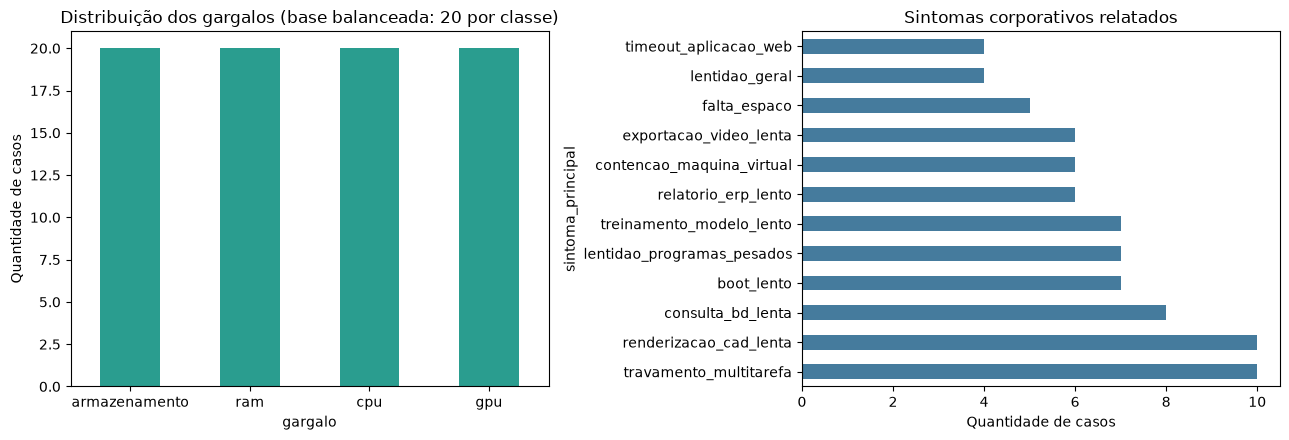

Casos por perfil de carga x gargalo:


gargalo,armazenamento,cpu,gpu,ram
perfil_carga,,,,
atendimento_cliente,3,0,0,4
banco_de_dados,5,2,0,2
ciencia_de_dados_ml,0,0,6,2
desenvolvimento_software,2,5,0,3
design_grafico_marketing,2,0,6,0
engenharia_cad,0,2,8,0
financeiro_erp,3,4,0,0
ofimatica_administrativa,5,0,0,4
servidor_aplicacao_web,0,5,0,0


In [ ]:
fig, eixos = plt.subplots(1, 2, figsize=(13, 4.5))

casos['gargalo'].value_counts().plot(kind='bar', ax=eixos[0], color='#2a9d8f')
eixos[0].set_title('Distribuição dos gargalos (base balanceada: 20 por classe)')
eixos[0].set_ylabel('Quantidade de casos')
eixos[0].tick_params(axis='x', rotation=0)

casos['sintoma_principal'].value_counts().plot(kind='barh', ax=eixos[1], color='#457b9d')
eixos[1].set_title('Sintomas corporativos relatados')
eixos[1].set_xlabel('Quantidade de casos')

plt.tight_layout()
plt.show()

print('Casos por perfil de carga x gargalo:')
pd.crosstab(casos['perfil_carga'], casos['gargalo'])

## 2. Pré-processamento: representando cada caso como vetor numérico

Para o KNN calcular distâncias, todo caso precisa virar um vetor de números:

- Atributos **ordinais** (geração da CPU, tipo de armazenamento, GPU) recebem uma escala que preserva a ordem de desempenho (ex.: HDD = 0 < SSD SATA = 1 < SSD NVMe = 2);
- Atributos **categóricos sem ordem** (tipo de máquina, perfil de carga, sintoma) viram colunas *one-hot* com **domínio fixo** definido pelo PRD;
- Todos os atributos são normalizados para o intervalo [0, 1] com `MinMaxScaler`, para que nenhuma variável (como RAM em GB) domine a distância euclidiana.

**Correção em relação à Entrega 2:** uma categoria fora do domínio (ex.: um sintoma digitado errado) quebrava a
vetorização silenciosamente. Agora `validar_dominios` verifica o caso antes e aponta exatamente qual valor é inválido.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

MAPA_CPU = {'antiga': 0, 'intermediaria': 1, 'recente': 2}
MAPA_ARMAZENAMENTO = {'HDD': 0, 'SSD_SATA': 1, 'SSD_NVMe': 2}
MAPA_GPU = {'integrada': 0, 'dedicada_baixa': 1, 'dedicada_media': 2, 'dedicada_alta': 3}

# Dominios fechados definidos na secao 5 do PRD
CATEGORIAS = {
    'tipo_maquina': ['desktop_escritorio', 'notebook_corporativo', 'servidor',
                     'estacao_trabalho', 'maquina_virtual'],
    'perfil_carga': ['ofimatica_administrativa', 'desenvolvimento_software', 'banco_de_dados',
                     'servidor_aplicacao_web', 'virtualizacao_vdi', 'engenharia_cad',
                     'design_grafico_marketing', 'atendimento_cliente', 'ciencia_de_dados_ml',
                     'financeiro_erp'],
    'sintoma_principal': ['boot_lento', 'travamento_multitarefa', 'lentidao_programas_pesados',
                          'lentidao_geral', 'falta_espaco', 'consulta_bd_lenta',
                          'timeout_aplicacao_web', 'contencao_maquina_virtual',
                          'renderizacao_cad_lenta', 'exportacao_video_lenta',
                          'treinamento_modelo_lento', 'relatorio_erp_lento'],
}
ORDINAIS = {'cpu_geracao': MAPA_CPU, 'tipo_armazenamento': MAPA_ARMAZENAMENTO, 'gpu': MAPA_GPU}

ATRIBUTOS = ['tipo_maquina', 'cpu_geracao', 'nucleos_cpu', 'ram_gb', 'tipo_armazenamento',
             'gpu', 'perfil_carga', 'sintoma_principal', 'uso_cpu_pct', 'uso_ram_pct', 'uso_disco_pct']

def validar_dominios(df):
    """Garante que todo valor categorico pertence ao dominio fechado do PRD (corrige o bug da Entrega 2)."""
    dominios = {**CATEGORIAS, **{col: list(mapa) for col, mapa in ORDINAIS.items()}}
    for coluna, validos in dominios.items():
        invalidos = set(df[coluna]) - set(validos)
        if invalidos:
            raise ValueError(f"Valores fora do dominio em '{coluna}': {sorted(invalidos)}. "
                             f"Validos: {validos}")

def vetorizar(df):
    """Converte casos (DataFrame) em vetores numéricos com colunas fixas."""
    validar_dominios(df)
    x = df[ATRIBUTOS].copy()
    for coluna, mapa in ORDINAIS.items():
        x[coluna] = x[coluna].map(mapa)
    for coluna, valores in CATEGORIAS.items():
        x[coluna] = pd.Categorical(x[coluna], categories=valores)
    return pd.get_dummies(x, columns=list(CATEGORIAS)).astype(float)

X_bruto = vetorizar(casos)
normalizador = MinMaxScaler().fit(X_bruto)
X = normalizador.transform(X_bruto)

print(f'Matriz de atributos: {X.shape[0]} casos x {X.shape[1]} atributos')
X_bruto.head(3)

Matriz de atributos: 80 casos x 35 atributos


,cpu_geracao,nucleos_cpu,ram_gb,tipo_armazenamento,gpu,uso_cpu_pct,uso_ram_pct,uso_disco_pct,tipo_maquina_desktop_escritorio,tipo_maquina_notebook_corporativo,...,sintoma_principal_lentidao_programas_pesados,sintoma_principal_lentidao_geral,sintoma_principal_falta_espaco,sintoma_principal_consulta_bd_lenta,sintoma_principal_timeout_aplicacao_web,sintoma_principal_contencao_maquina_virtual,sintoma_principal_renderizacao_cad_lenta,sintoma_principal_exportacao_video_lenta,sintoma_principal_treinamento_modelo_lento,sintoma_principal_relatorio_erp_lento
0,0.0,2.0,4.0,0.0,0.0,30.0,65.0,100.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,2.0,4.0,0.0,0.0,35.0,70.0,100.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1.0,4.0,8.0,0.0,0.0,28.0,60.0,95.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## 3. Etapa *Retrieve* — recuperando casos semelhantes com KNN

Dado um caso novo, o KNN calcula a **distância euclidiana** entre ele e todos os casos da base e devolve os
*k* vizinhos mais próximos — os casos históricos mais parecidos com a máquina analisada.

In [ ]:
from sklearn.neighbors import NearestNeighbors

modelo_knn = NearestNeighbors(n_neighbors=3, metric='euclidean').fit(X)

def recuperar_casos(caso_novo, k=3):
    """Etapa Retrieve: devolve os k casos históricos mais próximos do caso novo."""
    vetor = normalizador.transform(vetorizar(pd.DataFrame([caso_novo])))
    distancias, indices = modelo_knn.kneighbors(vetor, n_neighbors=k)
    semelhantes = casos.iloc[indices[0]].copy()
    semelhantes['distancia'] = distancias[0].round(3)
    return semelhantes

## 4. Etapa *Reuse* — adaptando a solução dos vizinhos

Com os vizinhos recuperados, o sistema identifica o **gargalo mais frequente** entre eles (votação majoritária)
e reutiliza a solução do caso mais próximo dentro desse gargalo, apresentando os casos que justificam a recomendação.

In [ ]:
def recomendar_upgrade(caso_novo, k=3):
    """Ciclo Retrieve + Reuse: diagnostica o gargalo e recomenda o upgrade."""
    semelhantes = recuperar_casos(caso_novo, k=k)
    gargalo = semelhantes['gargalo'].mode()[0]
    solucao = semelhantes[semelhantes['gargalo'] == gargalo].iloc[0]['solucao_recomendada']

    print(f'Provável gargalo........: {gargalo.upper()}')
    print(f'Upgrade recomendado.....: {solucao}')
    print(f'\nCasos que sustentam a recomendação (k={k}):')
    colunas = ['id_caso', 'tipo_maquina', 'perfil_carga', 'sintoma_principal', 'gargalo',
               'solucao_recomendada', 'distancia']
    return semelhantes[colunas].reset_index(drop=True)

In [ ]:
# Caso de teste 1: servidor de banco de dados com HDD e consultas lentas (disco saturado)
caso_teste_1 = {
    'tipo_maquina': 'servidor', 'cpu_geracao': 'intermediaria', 'nucleos_cpu': 8, 'ram_gb': 32,
    'tipo_armazenamento': 'HDD', 'gpu': 'integrada', 'perfil_carga': 'banco_de_dados',
    'sintoma_principal': 'consulta_bd_lenta', 'uso_cpu_pct': 48, 'uso_ram_pct': 70, 'uso_disco_pct': 99,
}
recomendar_upgrade(caso_teste_1)

Provável gargalo........: ARMAZENAMENTO
Upgrade recomendado.....: migrar banco para SSD NVMe

Casos que sustentam a recomendação (k=3):


,id_caso,tipo_maquina,perfil_carga,sintoma_principal,gargalo,solucao_recomendada,distancia
0,6,servidor,banco_de_dados,consulta_bd_lenta,armazenamento,migrar banco para SSD NVMe,0.045
1,9,servidor,banco_de_dados,consulta_bd_lenta,armazenamento,migrar banco para SSD NVMe,0.523
2,7,servidor,banco_de_dados,consulta_bd_lenta,armazenamento,migrar banco para SSD NVMe,0.690


In [ ]:
# Caso de teste 2: estação de engenharia com GPU integrada e renderização CAD lenta
caso_teste_2 = {
    'tipo_maquina': 'estacao_trabalho', 'cpu_geracao': 'recente', 'nucleos_cpu': 8, 'ram_gb': 32,
    'tipo_armazenamento': 'SSD_NVMe', 'gpu': 'integrada', 'perfil_carga': 'engenharia_cad',
    'sintoma_principal': 'renderizacao_cad_lenta', 'uso_cpu_pct': 55, 'uso_ram_pct': 62, 'uso_disco_pct': 28,
}
recomendar_upgrade(caso_teste_2)

Provável gargalo........: GPU
Upgrade recomendado.....: trocar por GPU dedicada de alto desempenho

Casos que sustentam a recomendação (k=3):


,id_caso,tipo_maquina,perfil_carga,sintoma_principal,gargalo,solucao_recomendada,distancia
0,62,estacao_trabalho,engenharia_cad,renderizacao_cad_lenta,gpu,trocar por GPU dedicada de alto desempenho,0.509
1,67,estacao_trabalho,engenharia_cad,renderizacao_cad_lenta,gpu,instalar GPU dedicada intermediaria,0.512
2,63,estacao_trabalho,engenharia_cad,renderizacao_cad_lenta,gpu,trocar por GPU com mais VRAM,0.708


In [ ]:
# Caso de teste 3: VM de aplicação web com timeout e CPU saturada
caso_teste_3 = {
    'tipo_maquina': 'maquina_virtual', 'cpu_geracao': 'intermediaria', 'nucleos_cpu': 2, 'ram_gb': 8,
    'tipo_armazenamento': 'SSD_SATA', 'gpu': 'integrada', 'perfil_carga': 'servidor_aplicacao_web',
    'sintoma_principal': 'timeout_aplicacao_web', 'uso_cpu_pct': 96, 'uso_ram_pct': 70, 'uso_disco_pct': 35,
}
recomendar_upgrade(caso_teste_3)

Provável gargalo........: CPU
Upgrade recomendado.....: aumentar vCPUs da maquina virtual

Casos que sustentam a recomendação (k=3):


,id_caso,tipo_maquina,perfil_carga,sintoma_principal,gargalo,solucao_recomendada,distancia
0,48,maquina_virtual,servidor_aplicacao_web,timeout_aplicacao_web,cpu,aumentar vCPUs da maquina virtual,0.061
1,49,maquina_virtual,servidor_aplicacao_web,timeout_aplicacao_web,cpu,aumentar vCPUs da maquina virtual,0.723
2,47,servidor,servidor_aplicacao_web,timeout_aplicacao_web,cpu,adicionar nucleos ou escalar horizontalmente,1.460


## 5. Etapa *Revise* — validando e corrigindo o diagnóstico

O ciclo RBC não termina na sugestão. Na etapa **Revise**, um especialista (ou o próprio uso da máquina)
**confirma ou corrige** o gargalo proposto pelo *Reuse*. Usamos a **confiança** — a fração dos *k*
vizinhos que concordam com o gargalo escolhido — como sinal de quando desconfiar: quanto menor a
concordância, mais o caso merece revisão humana. Se o especialista discorda, o diagnóstico é corrigido
antes de seguir para o *Retain*.

In [ ]:
def diagnosticar(caso, k=3):
    """Retrieve + Reuse: devolve o gargalo sugerido e a confianca (fracao de vizinhos concordantes)."""
    viz = recuperar_casos(caso, k=k)
    gargalo = viz['gargalo'].mode()[0]
    confianca = (viz['gargalo'] == gargalo).mean()
    return gargalo, confianca

def revisar(gargalo_sugerido, gargalo_correto=None):
    """Revise: o especialista confirma (gargalo_correto None ou igual) ou corrige a sugestao."""
    if gargalo_correto is None or gargalo_correto == gargalo_sugerido:
        return gargalo_sugerido, False
    return gargalo_correto, True

# Caso ambiguo: 'consulta_bd_lenta' pode ser disco, RAM ou CPU.
sugerido, confianca = diagnosticar(caso_teste_1)
print(f'Reuse sugere: {sugerido.upper()} (confianca {confianca:.0%})')

# 1) Especialista concorda -> diagnostico confirmado
final, revisado = revisar(sugerido)
print(f'  sem correcao : {final.upper():<14} | revisado={revisado}')

# 2) Especialista discorda -> diagnostico corrigido para RAM
final, revisado = revisar(sugerido, gargalo_correto='ram')
print(f'  com correcao : {final.upper():<14} | revisado={revisado}')

## 6. Etapa *Retain* — aprendendo com o caso resolvido

Com o diagnóstico revisado, a etapa **Retain** guarda o novo caso (configuração + telemetria +
gargalo confirmado + solução) de volta na base. Assim o sistema **aprende**: da próxima vez que uma
máquina parecida aparecer, o caso recém-aprendido já estará entre os vizinhos candidatos. É o que
fecha os **4 R** do RBC — *Retrieve → Reuse → Revise → Retain*.

In [ ]:
def reter_caso(base, caso, gargalo, solucao):
    """Retain: incorpora o caso confirmado a base de casos, devolvendo a base ampliada."""
    novo = {**caso, 'id_caso': int(base['id_caso'].max()) + 1,
            'gargalo': gargalo, 'solucao_recomendada': solucao}
    return pd.concat([base, pd.DataFrame([novo])], ignore_index=True)

casos_ampliada = reter_caso(casos, caso_teste_1, gargalo='armazenamento',
                            solucao='migrar banco para SSD NVMe')
print(f'Base apos Retain: {len(casos)} -> {len(casos_ampliada)} casos '
      f'(id do novo caso: {int(casos_ampliada.iloc[-1].id_caso)})')

## 7. Avaliação do *Retain* — o sistema realmente aprende?

Para medir o valor do *Retain*, usamos **aprendizado incremental (*test-then-train*)**: partimos de uma
base pequena (semente de 24 casos, 6 por gargalo) e apresentamos os 56 casos restantes **um a um**.
Cada caso é primeiro **diagnosticado** (Retrieve + Reuse), depois **revisado** com o rótulo real e só
então, na condição *com Retain*, **retido** na base. Comparamos com um controle em que a base fica
**congelada** (sem Retain). Se o *Retain* funciona, aprender com cada caso deve elevar a acurácia ao
longo do fluxo.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

def avaliar_retain(com_retain, seed=42):
    """Aprendizado incremental: diagnostica cada caso do fluxo antes de (opcionalmente) rete-lo."""
    semente = casos.groupby('gargalo', group_keys=False).sample(n=6, random_state=seed)
    fluxo = casos.drop(semente.index).sample(frac=1, random_state=seed).reset_index(drop=True)
    base = semente.reset_index(drop=True)
    acertos = []
    for _, novo in fluxo.iterrows():
        Xb = vetorizar(base)
        norm = MinMaxScaler().fit(Xb)
        clf = KNeighborsClassifier(n_neighbors=3, metric='euclidean').fit(norm.transform(Xb), base['gargalo'])
        vetor = norm.transform(vetorizar(pd.DataFrame([novo])).reindex(columns=Xb.columns, fill_value=0.0))
        previsto = clf.predict(vetor)[0]                    # Retrieve + Reuse
        acertos.append(int(previsto == novo['gargalo']))    # Revise: compara com o rotulo real
        if com_retain:                                      # Retain do caso confirmado
            base = pd.concat([base, novo.to_frame().T], ignore_index=True)
    return acertos

for flag, nome in [(False, 'SEM Retain (base congelada em 24)'), (True, 'COM Retain (base cresce 24->80)')]:
    a = avaliar_retain(flag)
    meio = len(a) // 2
    print(f'{nome}: acuracia no fluxo = {sum(a)/len(a):.1%} '
          f'| 1a metade {sum(a[:meio])/meio:.1%} -> 2a metade {sum(a[meio:])/(len(a)-meio):.1%}')

## 8. Avaliação do *Retrieve + Reuse* (base completa)

Usamos **validação leave-one-out**: cada caso é retirado da base, o KNN tenta identificar o gargalo dele usando
os 79 restantes, e comparamos com o diagnóstico real. Além da acurácia, avaliamos **precisão/revocação por classe**,
já que agora as quatro classes estão perfeitamente balanceadas (critério do PRD: acurácia ≥ 75% com k=3).

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import LeaveOneOut, cross_val_predict
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y = casos['gargalo']
classificador = KNeighborsClassifier(n_neighbors=3, metric='euclidean')
previsoes = cross_val_predict(classificador, X, y, cv=LeaveOneOut())

print(f'Acurácia (leave-one-out, k=3): {accuracy_score(y, previsoes):.1%}\n')

rotulos = sorted(y.unique())
print('Métricas por classe:')
print(classification_report(y, previsoes, labels=rotulos, digits=2))

matriz = confusion_matrix(y, previsoes, labels=rotulos)
print('Matriz de confusão (linhas = real, colunas = previsto):')
pd.DataFrame(matriz, index=rotulos, columns=rotulos)

Acurácia (leave-one-out, k=3): 80.0%

Métricas por classe:
               precision    recall  f1-score   support

armazenamento       0.76      0.80      0.78        20
          cpu       0.82      0.70      0.76        20
          gpu       0.80      1.00      0.89        20
          ram       0.82      0.70      0.76        20

     accuracy                           0.80        80
    macro avg       0.80      0.80      0.80        80
 weighted avg       0.80      0.80      0.80        80

Matriz de confusão (linhas = real, colunas = previsto):


,armazenamento,cpu,gpu,ram
armazenamento,16,2,1,1
cpu,2,14,2,2
gpu,0,0,20,0
ram,3,1,2,14


In [ ]:
# Sensibilidade ao valor de k: qual quantidade de vizinhos funciona melhor?
for k in [1, 3, 5, 7]:
    p = cross_val_predict(KNeighborsClassifier(n_neighbors=k, metric='euclidean'), X, y, cv=LeaveOneOut())
    print(f'k={k}: acurácia = {accuracy_score(y, p):.1%}')

k=1: acurácia = 83.8%


k=3: acurácia = 80.0%


k=5: acurácia = 80.0%


k=7: acurácia = 76.2%


In [ ]:
# Onde o KNN erra? Principalmente nos casos deliberadamente ambíguos,
# em que o mesmo sintoma pode ter gargalos diferentes e a telemetria decide.
erros = casos.loc[y != previsoes, ['id_caso', 'perfil_carga', 'sintoma_principal', 'gargalo']].copy()
erros['previsto'] = previsoes[y != previsoes]
print(f'{len(erros)} erros em {len(casos)} casos:')
erros.reset_index(drop=True)

16 erros em 80 casos:


,id_caso,perfil_carga,sintoma_principal,gargalo,previsto
0,4,ofimatica_administrativa,lentidao_geral,armazenamento,ram
1,14,financeiro_erp,relatorio_erp_lento,armazenamento,cpu
2,15,financeiro_erp,relatorio_erp_lento,armazenamento,cpu
3,18,design_grafico_marketing,falta_espaco,armazenamento,gpu
4,35,desenvolvimento_software,travamento_multitarefa,ram,armazenamento
5,36,desenvolvimento_software,lentidao_programas_pesados,ram,cpu
6,37,ciencia_de_dados_ml,treinamento_modelo_lento,ram,gpu
7,38,ciencia_de_dados_ml,lentidao_programas_pesados,ram,gpu
8,39,banco_de_dados,consulta_bd_lenta,ram,armazenamento
9,40,banco_de_dados,consulta_bd_lenta,ram,armazenamento


## 9. O sistema em produção — `src/modelo_ia/servico.py`

As seções anteriores implementaram o ciclo RBC **passo a passo**, para expor como cada etapa funciona. Esse mesmo
ciclo está empacotado no repositório como a classe **`HardwareRecommender`** (`src/modelo_ia/servico.py`) — é ela
que a **interface web** (seção 10) consome. A classe expõe as quatro etapas como métodos
(`recomendar_upgrade` → *Retrieve+Reuse*, `revisar` → *Revise*, `reter_caso` → *Retain*) e traz dois refinamentos
em relação ao código didático acima:

- a **acurácia leave-one-out** é calculada com o `MinMaxScaler` dentro de um `Pipeline`, reajustado a cada dobra —
  evitando o vazamento de dados de normalizar a base inteira antes da validação;
- os casos semelhantes ganham uma **similaridade legível** (`1 / (1 + distância)`, de 1,0 idêntico a 0,0 distante),
  que é o número exibido na interface;
- a vetorização é ancorada nos **domínios fechados do PRD**, e não nos valores presentes na base, para que as
  colunas *one-hot* continuem estáveis depois que o *Retain* injeta casos novos.

Como o notebook agora clona o repositório inteiro, o serviço pode ser importado e exercitado aqui mesmo.

In [ ]:
from modelo_ia import HardwareRecommender

# Carrega data/base_casos_corporativa_v1.csv e treina o KNN (mesma base das secoes anteriores).
modelo = HardwareRecommender(k=3)
resumo = modelo.metricas_resumo()

print(f'Casos na base.............: {resumo["total_casos"]}')
print(f'Atributos vetorizados.....: {resumo["total_atributos"]}')
print(f'Acuracia (leave-one-out)..: {resumo["acuracia_loo"]:.1%}')
print(f'Gargalos..................: {", ".join(resumo["gargalos"])}')

In [ ]:
# Os 4 R pela API do servico, no mesmo caso de teste 1 da secao 4 (servidor de BD com HDD).
resultado = modelo.recomendar_upgrade(caso_teste_1)            # Retrieve + Reuse
print(f'Reuse sugere....: {resultado.gargalo.upper()} (confianca {resultado.confianca:.0%})')
print(f'Upgrade sugerido: {resultado.solucao}')

revisao = modelo.revisar(resultado)                            # Revise (especialista confirma)
print(f'Apos Revise.....: {revisao.gargalo_final.upper()} | revisado={revisao.revisado}')

novo_id = modelo.reter_caso(caso_teste_1, revisao.gargalo_final, revisao.solucao_final)   # Retain
print(f'Apos Retain.....: caso #{novo_id} incorporado -> base com {len(modelo.casos)} casos')

print('\nCasos semelhantes, com a similaridade exibida na interface:')
colunas = ['id_caso', 'tipo_maquina', 'sintoma_principal', 'gargalo', 'solucao_recomendada', 'similaridade']
resultado.semelhantes[colunas].reset_index(drop=True)

## 10. A interface web (Streamlit)

O repositório entrega também uma **interface gráfica** (`src/app.py`), construída sobre o serviço da seção 9,
com duas páginas:

- **Nova análise** (`src/pages/analise.py`) — formulário com a configuração da máquina, o perfil de carga, o
  sintoma e a telemetria; devolve o gargalo provável, o upgrade recomendado e os casos semelhantes que
  sustentam a recomendação (com a barra de similaridade). Ao enviar, o caso passa por *Revise* + *Retain* e
  **entra na base**, fechando o ciclo em uso real;
- **Indicadores** (`src/pages/dashboard.py`) — total de casos, atributos vetorizados, acurácia leave-one-out,
  distribuição de gargalos por tipo de máquina, gargalos e sintomas mais frequentes (gráficos Plotly de
  `src/components/layout_graficos.py`) e a base completa com filtro e download em CSV.

A célula abaixo **sobe o app a partir deste notebook**. No Colab, que não expõe portas ao navegador, ela publica
um **endereço público temporário** via `cloudflared` — abra o link impresso para usar a interface. Localmente o
app fica em `http://localhost:8501` (equivalente a rodar `streamlit run src/app.py`).

In [ ]:
import re
import time

PORTA = 8501

if EM_COLAB:
    # O Colab nao traz o Streamlit; as demais dependencias ja existem no ambiente.
    subprocess.run([sys.executable, '-m', 'pip', 'install', '--quiet', 'streamlit'], check=True)

# cwd = RAIZ (definido na secao 0), entao o .streamlit/config.toml do repositorio e aplicado.
app = subprocess.Popen(
    [sys.executable, '-m', 'streamlit', 'run', 'src/app.py',
     '--server.port', str(PORTA), '--server.headless', 'true'],
    cwd=RAIZ, stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL,
)
time.sleep(10)  # tempo para o servidor subir

tunel = None
if EM_COLAB:
    # Tunel publico para a porta do Streamlit (binario oficial do cloudflared).
    if not Path('cloudflared').exists():
        subprocess.run(['wget', '--quiet', '-O', 'cloudflared',
                        'https://github.com/cloudflare/cloudflared/releases/latest/download/'
                        'cloudflared-linux-amd64'], check=True)
        Path('cloudflared').chmod(0o755)

    with open('cloudflared.log', 'w') as registro:
        tunel = subprocess.Popen(['./cloudflared', 'tunnel', '--url', f'http://localhost:{PORTA}'],
                                 stdout=registro, stderr=subprocess.STDOUT)

    endereco, limite = None, time.time() + 60
    while endereco is None and time.time() < limite:
        time.sleep(2)
        achado = re.search(r'https://[-\w]+\.trycloudflare\.com', Path('cloudflared.log').read_text())
        endereco = achado.group(0) if achado else None

    print(f'Interface web publicada em: {endereco}' if endereco
          else 'Nao foi possivel abrir o tunel; confira o cloudflared.log.')
else:
    print(f'Interface web disponivel em: http://localhost:{PORTA}')

In [ ]:
# Encerra a interface web (e o tunel) ao terminar a demonstracao.
app.terminate()
if tunel is not None:
    tunel.terminate()
print('Interface web encerrada.')

## 11. Conclusões

- A migração para o contexto corporativo **manteve a acurácia de 80% com k=3** (baseline da Entrega 2),
  agora com uma base **duas vezes maior** (80 vs 40 casos), **perfeitamente balanceada** (20 casos por gargalo,
  contra 14×7 na v1) e com **mais que o dobro de diversidade** (5 tipos de máquina, 10 perfis de carga, 12 sintomas);
- Os erros se concentram nos **casos propositalmente ambíguos** (ex.: `consulta_bd_lenta` como disco, RAM ou CPU),
  em que sintomas idênticos exigem que a telemetria desempate — exatamente o comportamento esperado de um RBC;
- A classe `gpu` atinge 100% de acerto, refletindo o padrão causa-efeito espelhado do dataset de FPS
  (carga gráfica + GPU insuficiente → gargalo de GPU), transplantado para CAD, design e ML.

- O **ciclo RBC completo (4 R)** esta implementado: alem de *Retrieve* e *Reuse*, a etapa *Revise* confirma/corrige o diagnostico e a etapa *Retain* incorpora o caso resolvido a base. No experimento de **aprendizado incremental** (secao 7), ligar o *Retain* elevou a acuracia no fluxo de **67,9% para 80,4%** (com a 2a metade do fluxo, ja com base maior, chegando a **85,7%**) — evidencia direta de que o sistema aprende ao reter casos.

### Roadmap (v2 — pós-entrega)

- `cpu_score`/`gpu_score` numéricos via join com benchmarks reais (PassMark/Geekbench);
- `criticidade_negocio` e `custo_estimado_solucao` para priorização corporativa de upgrades;
- **Pesos por atributo** na distância (sintoma deve pesar mais que tipo de máquina), como na fórmula de
  similaridade ponderada de Lohmann, Gaspary & Melchiors (SBSeg 2005);
- Coleta real de telemetria com `psutil` em máquinas de laboratório (com anonimização LGPD);
- **Persistência** dos casos retidos (Retain gravando em disco) e coleta de feedback real do especialista pela interface de demonstração.